# B2B Specialty Coffee Wholesale Pricing, Equipment CAPEX Subsidization & Account Economics Engine

This notebook models the commercial economics of B2B specialty coffee wholesale accounts across the New Zealand hospitality market. It evaluates account profitability across volume tiers (kg/week), calculates equipment CAPEX payback periods for subsidized espresso machinery (e.g., commercial 2-group/3-group setups), factors in logistical cost-to-serve, and runs sensitivity analysis to optimize contract margin performance. Designed to empower commercial sales teams and business development managers to make data-backed pricing and account acquisition decisions.

In [1]:
# Installs and Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Configure plot aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100

print("All libraries successfully imported and configured.")

All libraries successfully imported and configured.


In [2]:
# Data Pipeline: Synthetic B2B Account Generator (NZ Hospitality Market)

def generate_nz_wholesale_accounts(num_accounts=60, random_seed=42):
    """
    Generates a realistic dataset of New Zealand café and commercial hospitality accounts.
    """
    np.random.seed(random_seed)

    account_ids = [f"ACC-AKL-{1001 + i}" for i in range(num_accounts)]

    regions = np.random.choice(
        ['Auckland Central', 'Freemans Bay / Ponsonby', 'North Shore', 'Wellington CBD', 'Hamilton', 'Tauranga'],
        size=num_accounts,
        p=[0.30, 0.25, 0.15, 0.15, 0.08, 0.07]
    )

    brand_portfolios = np.random.choice(
        ['Flagship Specialty Blend', 'Multi-Brand Portfolio'],
        size=num_accounts,
        p=[0.75, 0.25]
    )

    # Weekly coffee volume in kg (Gamma distribution to mimic real hospitality skew)
    weekly_volume_kg = np.random.gamma(shape=3.2, scale=12.5, size=num_accounts).round(1)
    weekly_volume_kg = np.clip(weekly_volume_kg, 12.0, 160.0)

    # Machinery CAPEX ($NZD) assigned based on volume demand
    equipment_capex = []
    for vol in weekly_volume_kg:
        if vol < 30:
            equipment_capex.append(12500) # 2-Group Espresso Machine + Grinder
        elif vol < 70:
            equipment_capex.append(18500) # 3-Group High Spec Machine + Dual Grinders
        else:
            equipment_capex.append(27000) # Dual 3-Group Commercial Setups

    contract_terms_months = np.random.choice([12, 24, 36], size=num_accounts, p=[0.20, 0.50, 0.30])

    df = pd.DataFrame({
        'Account_ID': account_ids,
        'Region': regions,
        'Brand_Portfolio': brand_portfolios,
        'Weekly_Volume_KG': weekly_volume_kg,
        'Equipment_CAPEX_NZD': equipment_capex,
        'Contract_Term_Months': contract_terms_months
    })

    return df

raw_accounts_df = generate_nz_wholesale_accounts()
print(f"Dataset generated: {len(raw_accounts_df)} B2B Accounts.")
raw_accounts_df.head()

Dataset generated: 60 B2B Accounts.


,Account_ID,Region,Brand_Portfolio,Weekly_Volume_KG,Equipment_CAPEX_NZD,Contract_Term_Months
0,ACC-AKL-1001,Freemans Bay / Ponsonby,Flagship Specialty Blend,22.9,12500,24
1,ACC-AKL-1002,Tauranga,Flagship Specialty Blend,29.3,12500,24
2,ACC-AKL-1003,Wellington CBD,Multi-Brand Portfolio,42.5,18500,36
3,ACC-AKL-1004,North Shore,Flagship Specialty Blend,41.6,18500,24
4,ACC-AKL-1005,Auckland Central,Flagship Specialty Blend,13.5,12500,12


In [3]:
# Commercial Financial Engine: Tiered Pricing, CAPEX Amortization, and Account Economics

def Engine_Commercial_Economics(
    df,
    base_wholesale_price=36.00,  # Standard NZD wholesale price per kg
    cogs_per_kg=14.20,           # Raw green beans, roasting, packaging cost per kg
    delivery_cost_per_order=22.00,# Freight/courier cost per weekly delivery
    monthly_support_cost=120.00  # Tech support, barista training, account manager visits
):
    """
    Computes tiered pricing structure, gross contribution, logistics cost-to-serve,
    equipment payback period, and net contribution margin.
    """
    model_df = df.copy()

    # 1. Volume-based Tier Pricing ($/kg)
    def determine_tiered_price(vol):
        if vol >= 100:
            return base_wholesale_price - 6.50  # Tier 4: $29.50/kg
        elif vol >= 60:
            return base_wholesale_price - 4.50  # Tier 3: $31.50/kg
        elif vol >= 30:
            return base_wholesale_price - 2.50  # Tier 2: $33.50/kg
        else:
            return base_wholesale_price         # Tier 1: $36.00/kg

    model_df['Wholesale_Price_Per_KG'] = model_df['Weekly_Volume_KG'].apply(determine_tiered_price)
    model_df['Annual_Volume_KG'] = model_df['Weekly_Volume_KG'] * 52

    # 2. Revenue & Gross Profit
    model_df['Annual_Wholesale_Revenue'] = model_df['Annual_Volume_KG'] * model_df['Wholesale_Price_Per_KG']
    model_df['Annual_COGS'] = model_df['Annual_Volume_KG'] * cogs_per_kg
    model_df['Annual_Gross_Profit'] = model_df['Annual_Wholesale_Revenue'] - model_df['Annual_COGS']
    model_df['Gross_Margin_Pct'] = (model_df['Annual_Gross_Profit'] / model_df['Annual_Wholesale_Revenue']) * 100

    # 3. Cost-To-Serve (Logistics + Barista/Tech Support)
    annual_deliveries = 52
    model_df['Annual_Logistics_Cost'] = annual_deliveries * delivery_cost_per_order
    model_df['Annual_Support_Cost'] = monthly_support_cost * 12
    model_df['Annual_Total_Cost_To_Serve'] = model_df['Annual_Logistics_Cost'] + model_df['Annual_Support_Cost']

    # 4. Equipment Subsidization Amortization
    model_df['Annual_Equipment_Amortization'] = (model_df['Equipment_CAPEX_NZD'] / model_df['Contract_Term_Months']) * 12

    # 5. Net Contribution Margin ($ & %)
    model_df['Annual_Net_Contribution'] = (
        model_df['Annual_Gross_Profit']
        - model_df['Annual_Total_Cost_To_Serve']
        - model_df['Annual_Equipment_Amortization']
    )

    model_df['Net_Margin_Pct'] = (model_df['Annual_Net_Contribution'] / model_df['Annual_Wholesale_Revenue']) * 100

    # 6. Equipment Payback Period (Months)
    monthly_operating_profit = (model_df['Annual_Gross_Profit'] - model_df['Annual_Total_Cost_To_Serve']) / 12

    model_df['Equipment_Payback_Months'] = np.where(
        monthly_operating_profit > 0,
        (model_df['Equipment_CAPEX_NZD'] / monthly_operating_profit).round(1),
        999.0
    )

    # 7. Commercial Deal Assessment Status
    conditions = [
        (model_df['Equipment_Payback_Months'] <= model_df['Contract_Term_Months']) & (model_df['Net_Margin_Pct'] >= 20.0),
        (model_df['Equipment_Payback_Months'] <= model_df['Contract_Term_Months']) & (model_df['Net_Margin_Pct'] < 20.0),
        (model_df['Equipment_Payback_Months'] > model_df['Contract_Term_Months'])
    ]
    choices = ['Target Deal (High Yield)', 'Approved (Low Margin)', 'Unviable (Restructure Needed)']

    model_df['Commercial_Status'] = np.select(conditions, choices, default='Under Review')

    return model_df

processed_accounts = Engine_Commercial_Economics(raw_accounts_df)
processed_accounts.head()

,Account_ID,Region,Brand_Portfolio,Weekly_Volume_KG,Equipment_CAPEX_NZD,Contract_Term_Months,Wholesale_Price_Per_KG,Annual_Volume_KG,Annual_Wholesale_Revenue,Annual_COGS,Annual_Gross_Profit,Gross_Margin_Pct,Annual_Logistics_Cost,Annual_Support_Cost,Annual_Total_Cost_To_Serve,Annual_Equipment_Amortization,Annual_Net_Contribution,Net_Margin_Pct,Equipment_Payback_Months,Commercial_Status
0,ACC-AKL-1001,Freemans Bay / Ponsonby,Flagship Specialty Blend,22.9,12500,24,36.0,1190.8,42868.8,16909.36,25959.44,60.555556,1144.0,1440.0,2584.0,6250.000000,17125.440000,39.948494,6.4,Target Deal (High Yield)
1,ACC-AKL-1002,Tauranga,Flagship Specialty Blend,29.3,12500,24,36.0,1523.6,54849.6,21635.12,33214.48,60.555556,1144.0,1440.0,2584.0,6250.000000,24380.480000,44.449695,4.9,Target Deal (High Yield)
2,ACC-AKL-1003,Wellington CBD,Multi-Brand Portfolio,42.5,18500,36,33.5,2210.0,74035.0,31382.00,42653.00,57.611940,1144.0,1440.0,2584.0,6166.666667,33902.333333,45.792305,5.5,Target Deal (High Yield)
3,ACC-AKL-1004,North Shore,Flagship Specialty Blend,41.6,18500,24,33.5,2163.2,72467.2,30717.44,41749.76,57.611940,1144.0,1440.0,2584.0,9250.000000,29915.760000,41.281794,5.7,Target Deal (High Yield)
4,ACC-AKL-1005,Auckland Central,Flagship Specialty Blend,13.5,12500,12,36.0,702.0,25272.0,9968.40,15303.60,60.555556,1144.0,1440.0,2584.0,12500.000000,219.600000,0.868946,11.8,Approved (Low Margin)


In [4]:
# Executive Regional & Commercial Performance Summary

portfolio_summary = processed_accounts.groupby('Commercial_Status').agg(
    Total_Accounts=('Account_ID', 'count'),
    Avg_Weekly_Volume_KG=('Weekly_Volume_KG', 'mean'),
    Avg_Annual_Revenue=('Annual_Wholesale_Revenue', 'mean'),
    Avg_Net_Contribution=('Annual_Net_Contribution', 'mean'),
    Avg_Payback_Months=('Equipment_Payback_Months', 'mean')
).reset_index()

print("=========================================================================")
print("             B2B WHOLESALE PORTFOLIO COMMERCIAL SUMMARY                  ")
print("=========================================================================")
display(portfolio_summary)

             B2B WHOLESALE PORTFOLIO COMMERCIAL SUMMARY                  


,Commercial_Status,Total_Accounts,Avg_Weekly_Volume_KG,Avg_Annual_Revenue,Avg_Net_Contribution,Avg_Payback_Months
0,Approved (Low Margin),1,13.500000,25272.000000,219.600000,11.800000
1,Target Deal (High Yield),59,39.801695,68978.837288,27735.491751,6.371186


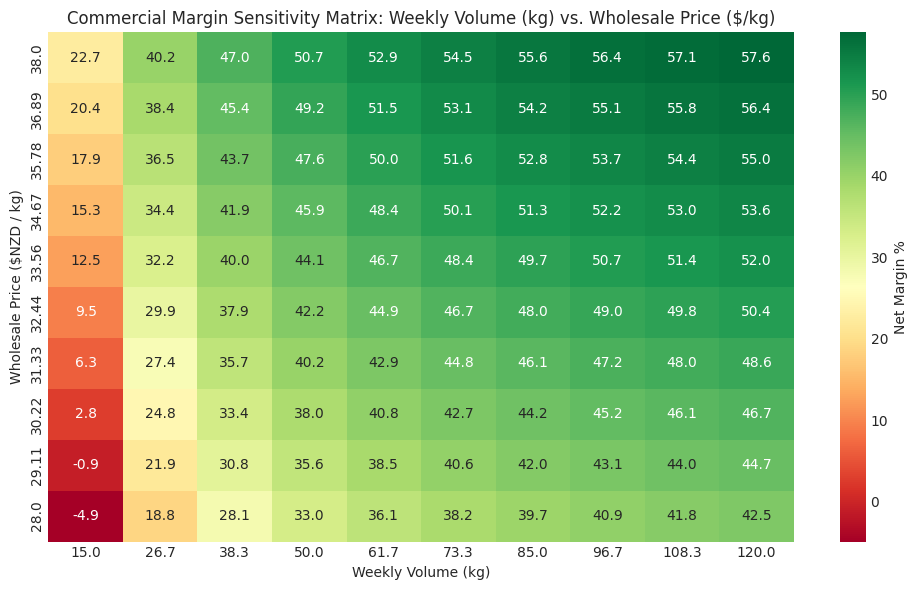

In [5]:
# Interactive Analytics & Sensitivity Visualizations

# 1. Plotly Interactive Scatter: Weekly Volume vs Payback Period by Deal Status
fig_scatter = px.scatter(
    processed_accounts,
    x='Weekly_Volume_KG',
    y='Equipment_Payback_Months',
    color='Commercial_Status',
    size='Annual_Wholesale_Revenue',
    hover_data=['Account_ID', 'Region', 'Brand_Portfolio', 'Contract_Term_Months'],
    title='B2B Account Viability: Weekly Coffee Volume (kg) vs. Equipment Payback Period (Months)',
    labels={'Weekly_Volume_KG': 'Weekly Volume (kg)', 'Equipment_Payback_Months': 'Payback Period (Months)'},
    color_discrete_map={
        'Target Deal (High Yield)': '#2ca02c',
        'Approved (Low Margin)': '#ff7f0e',
        'Unviable (Restructure Needed)': '#d62728'
    }
)

fig_scatter.add_hline(y=24, line_dash="dash", line_color="black", annotation_text="Standard 24-Month Contract Limit")
fig_scatter.show()

# 2. Seaborn Heatmap: Sensitivity Matrix (Volume vs Price Tier on Net Margin %)
volumes = np.linspace(15, 120, 10)
prices = np.linspace(28.00, 38.00, 10)
sensitivity_matrix = np.zeros((len(prices), len(volumes)))

cogs = 14.20
fixed_annual_costs = (22.00 * 52) + (120.00 * 12) + (18500 / 24 * 12) # Standardized for mid-tier equipment

for i, p in enumerate(prices):
    for j, v in enumerate(volumes):
        ann_vol = v * 52
        ann_rev = ann_vol * p
        ann_gross = ann_rev - (ann_vol * cogs)
        net_contrib = ann_gross - fixed_annual_costs
        net_margin_pct = (net_contrib / ann_rev) * 100
        sensitivity_matrix[i, j] = net_margin_pct

plt.figure(figsize=(10, 6))
sns.heatmap(
    sensitivity_matrix,
    xticklabels=np.round(volumes, 1),
    yticklabels=np.round(prices, 2),
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    cbar_kws={'label': 'Net Margin %'}
)
plt.title("Commercial Margin Sensitivity Matrix: Weekly Volume (kg) vs. Wholesale Price ($/kg)")
plt.xlabel("Weekly Volume (kg)")
plt.ylabel("Wholesale Price ($NZD / kg)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Project Summary & Executive Takeaway

This project models commercial engineering decisions for B2B specialty coffee wholesale account management. By evaluating wholesale volume tiers, equipment CAPEX subsidization payback dynamics, and logistics cost-to-serve across New Zealand hospitality clients, the tool automatically identifies high-yield accounts versus unviable deals requiring contract restructuring.

#### Resume-Ready Portfolio Bullet
* **Architected** an independent B2B commercial pricing and equipment CAPEX payback engine in Python, simulating account economics, margin sensitivity, and contract viability to optimize deal structuring across regional hospitality accounts.